<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Clustering and Dimensionality Reduction Project
Dataset: Wine Dataset


# Basics

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# 1. Load dataset

wine = load_wine()

# Convert to DataFrame for easier inspection
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())
print()

First 5 rows of the dataset:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  

# Data Pre-processing

In [3]:
# 2. Check for missing values

print("Missing values in each column:")
print(df.isnull().sum())
print()


Missing values in each column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64



Since there are no missing values, no imputation is needed. Since clustering and PCA are sensitive to scale, we need to standardize the features

In [5]:
# 3. Feature scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Model Implementation / Evaluation

K-mean Clustering

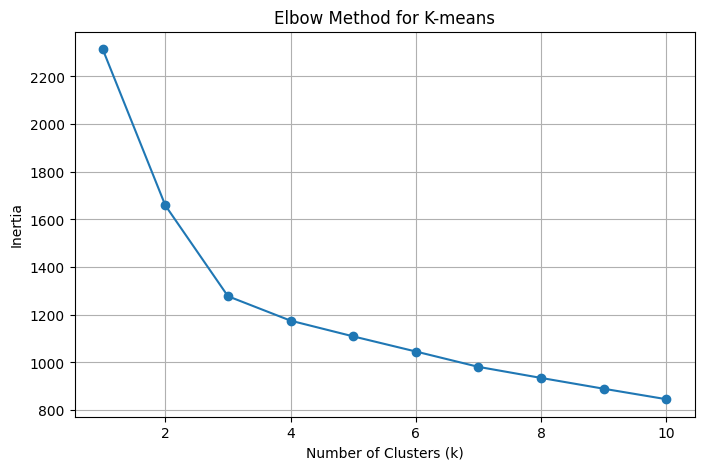

In [6]:

# 4. K-means clustering: Elbow Method

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for K-means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [7]:
# 5. Silhouette scores for K-means

print("Silhouette Scores for K-means:")
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, silhouette score = {score:.3f}")
print()

# Choose k = 3 based on elbow and silhouette results
kmeans_best = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_best.fit_predict(X_scaled)

Silhouette Scores for K-means:
k = 2, silhouette score = 0.259
k = 3, silhouette score = 0.285
k = 4, silhouette score = 0.260
k = 5, silhouette score = 0.202
k = 6, silhouette score = 0.237
k = 7, silhouette score = 0.204
k = 8, silhouette score = 0.157
k = 9, silhouette score = 0.150
k = 10, silhouette score = 0.144



Hierarchical clustering




Silhouette Scores for Agglomerative Clustering:
k = 2, silhouette score = 0.267
k = 3, silhouette score = 0.277
k = 4, silhouette score = 0.226
k = 5, silhouette score = 0.187
k = 6, silhouette score = 0.180
k = 7, silhouette score = 0.187
k = 8, silhouette score = 0.188
k = 9, silhouette score = 0.192
k = 10, silhouette score = 0.199



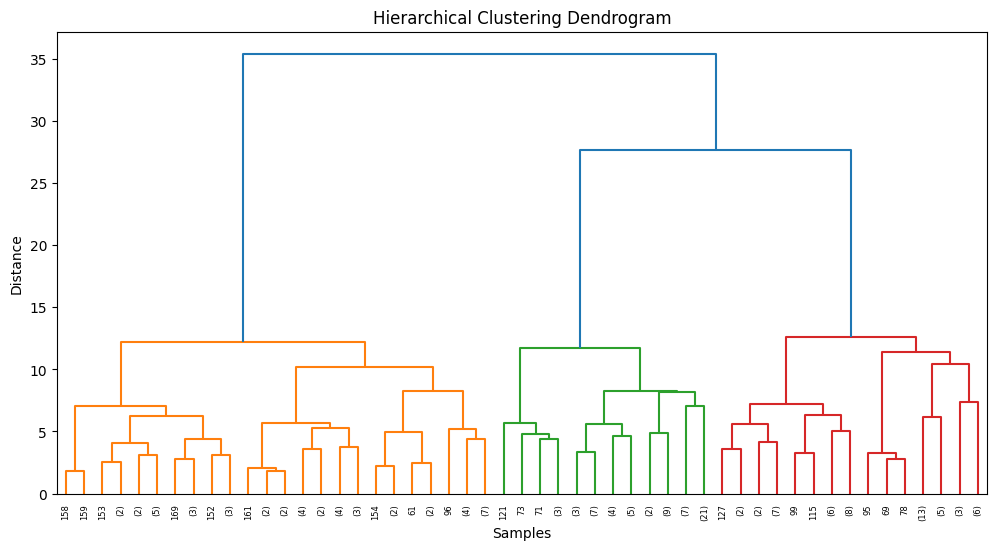

In [8]:
# 6. Hierarchical clustering

print("Silhouette Scores for Agglomerative Clustering:")
for k in range(2, 11):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, silhouette score = {score:.3f}")
print()

# Best hierarchical clustering with 3 clusters
agg_best = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_best.fit_predict(X_scaled)


# 7. Dendrogram for Hierarchical Clustering

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

PCA


In [9]:
# 8. PCA for dimensionality reduction

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio of first 2 PCA components:")
print(pca.explained_variance_ratio_)
print("Total explained variance by 2 components:",
      pca.explained_variance_ratio_.sum())
print()

Explained variance ratio of first 2 PCA components:
[0.36198848 0.1920749 ]
Total explained variance by 2 components: 0.5540633835693526



Vizualizations

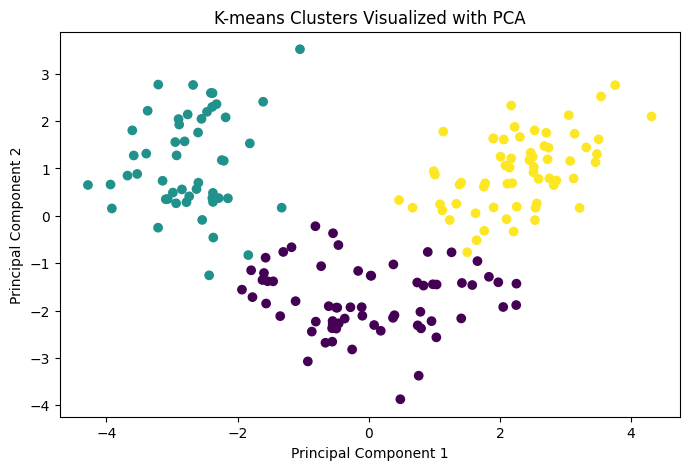

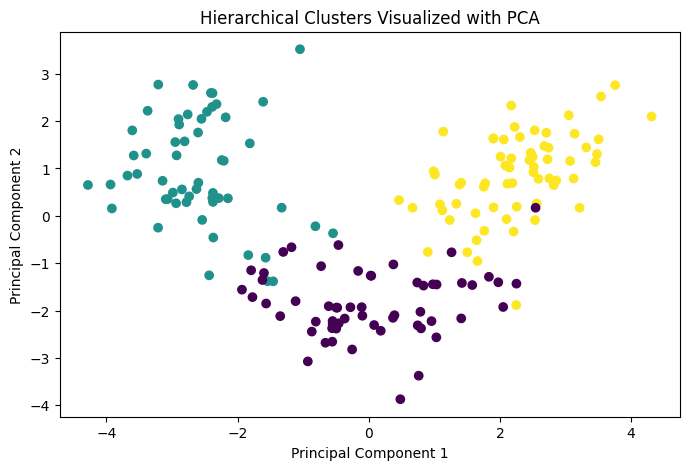

In [10]:
# Visualize K-means clusters in PCA space
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("K-means Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Visualize Hierarchical clusters in PCA space
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels)
plt.title("Hierarchical Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


Evaluation

In [12]:

# 10. Final model evaluation

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
agg_silhouette = silhouette_score(X_scaled, agg_labels)

print(f"Final K-means silhouette score: {kmeans_silhouette:.3f}")
print(f"Final Agglomerative silhouette score: {agg_silhouette:.3f}")


Final K-means silhouette score: 0.285
Final Agglomerative silhouette score: 0.277
